In [1]:
# ════════════════════════════════════════════════════════════════
# NOTEBOOK 1: Data Quality Assessment
# Business Audience: Data Engineering, Analytics Lead
# Purpose: Validate data completeness, consistency, distributions
# "Never analyze data you don't understand."
# ════════════════════════════════════════════════════════════════

import sys
sys.path.append("..")
from src.utils.analytics_config import *

print("=" * 60)
print("  DATA QUALITY ASSESSMENT")
print("  Supply Chain Intelligence Platform")
print("=" * 60)

✅ Analytics config loaded. Database connected.
  DATA QUALITY ASSESSMENT
  Supply Chain Intelligence Platform


In [2]:
# ── CELL 2: Load all tables ───────────────────────────────────────

tables = {
    "shipments"  : "SELECT * FROM fact_shipments",
    "suppliers"  : "SELECT * FROM dim_suppliers",
    "products"   : "SELECT * FROM dim_products",
    "warehouses" : "SELECT * FROM dim_warehouses",
    "inventory"  : "SELECT * FROM fact_inventory LIMIT 50000",
    "disruptions": "SELECT * FROM ref_disruption_events",
}

dfs = {name: get_df(sql) for name, sql in tables.items()}

# Convert date columns
for col in ["ship_date","planned_delivery_date","actual_delivery_date"]:
    dfs["shipments"][col] = pd.to_datetime(dfs["shipments"][col])

dfs["inventory"]["date"] = pd.to_datetime(dfs["inventory"]["date"])

print("Tables loaded successfully:")
for name, df in dfs.items():
    print(f"  {name:<15} {len(df):>8,} rows  |  {df.shape[1]} columns")

Tables loaded successfully:
  shipments          5,000 rows  |  19 columns
  suppliers             15 rows  |  10 columns
  products              75 rows  |  10 columns
  warehouses             7 rows  |  6 columns
  inventory         50,000 rows  |  12 columns
  disruptions            6 rows  |  11 columns


In [4]:
# ── CELL 3: Missing Value Analysis ───────────────────────────────
# WHY: Missing values silently corrupt KPI calculations
# e.g., if actual_delivery_date is NULL for delivered shipments → OTD wrong

def missing_value_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    total = len(df)
    report = pd.DataFrame({
        "column"       : df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_pct"  : (df.isnull().sum().values / total * 100).round(2),
        "dtype"        : df.dtypes.values.astype(str),
        "unique_values": df.nunique().values
    })
    report = report[report["missing_count"] > 0].sort_values(
        "missing_pct", ascending=False
    )
    return report

print("\n📋 MISSING VALUE REPORT — fact_shipments")
print("─" * 55)
mv = missing_value_report(dfs["shipments"], "shipments")
if len(mv) > 0:
    print(mv.to_string(index=False))
else:
    print("  No missing values in core columns ✓")

print("\n📋 EXPECTED NULLS (Business Logic Check)")
print("─" * 55)
# actual_delivery_date SHOULD be null for non-delivered shipments
# This is a data quality CHECK not an error
non_delivered = dfs["shipments"][dfs["shipments"]["status"] != "Delivered"]
delivered     = dfs["shipments"][dfs["shipments"]["status"] == "Delivered"]

print(f"""
  actual_delivery_date NULL for non-delivered:
  → {non_delivered['actual_delivery_date'].isnull().sum():,} / {len(non_delivered):,} rows
  → Expected: 100% null for non-delivered ✓

  actual_delivery_date NULL for delivered:
  → {delivered['actual_delivery_date'].isnull().sum():,} / {len(delivered):,} rows
  → Expected: 0 null for delivered ✓
""")


📋 MISSING VALUE REPORT — fact_shipments
───────────────────────────────────────────────────────
              column  missing_count  missing_pct          dtype  unique_values
    disruption_cause           4186        83.72            str              6
actual_delivery_date           1177        23.54 datetime64[us]            762
 actual_transit_days           1177        23.54        float64             99

📋 EXPECTED NULLS (Business Logic Check)
───────────────────────────────────────────────────────

  actual_delivery_date NULL for non-delivered:
  → 1,177 / 1,177 rows
  → Expected: 100% null for non-delivered ✓

  actual_delivery_date NULL for delivered:
  → 0 / 3,823 rows
  → Expected: 0 null for delivered ✓



  ✓ Saved: reports/figures/01_data_distributions.png


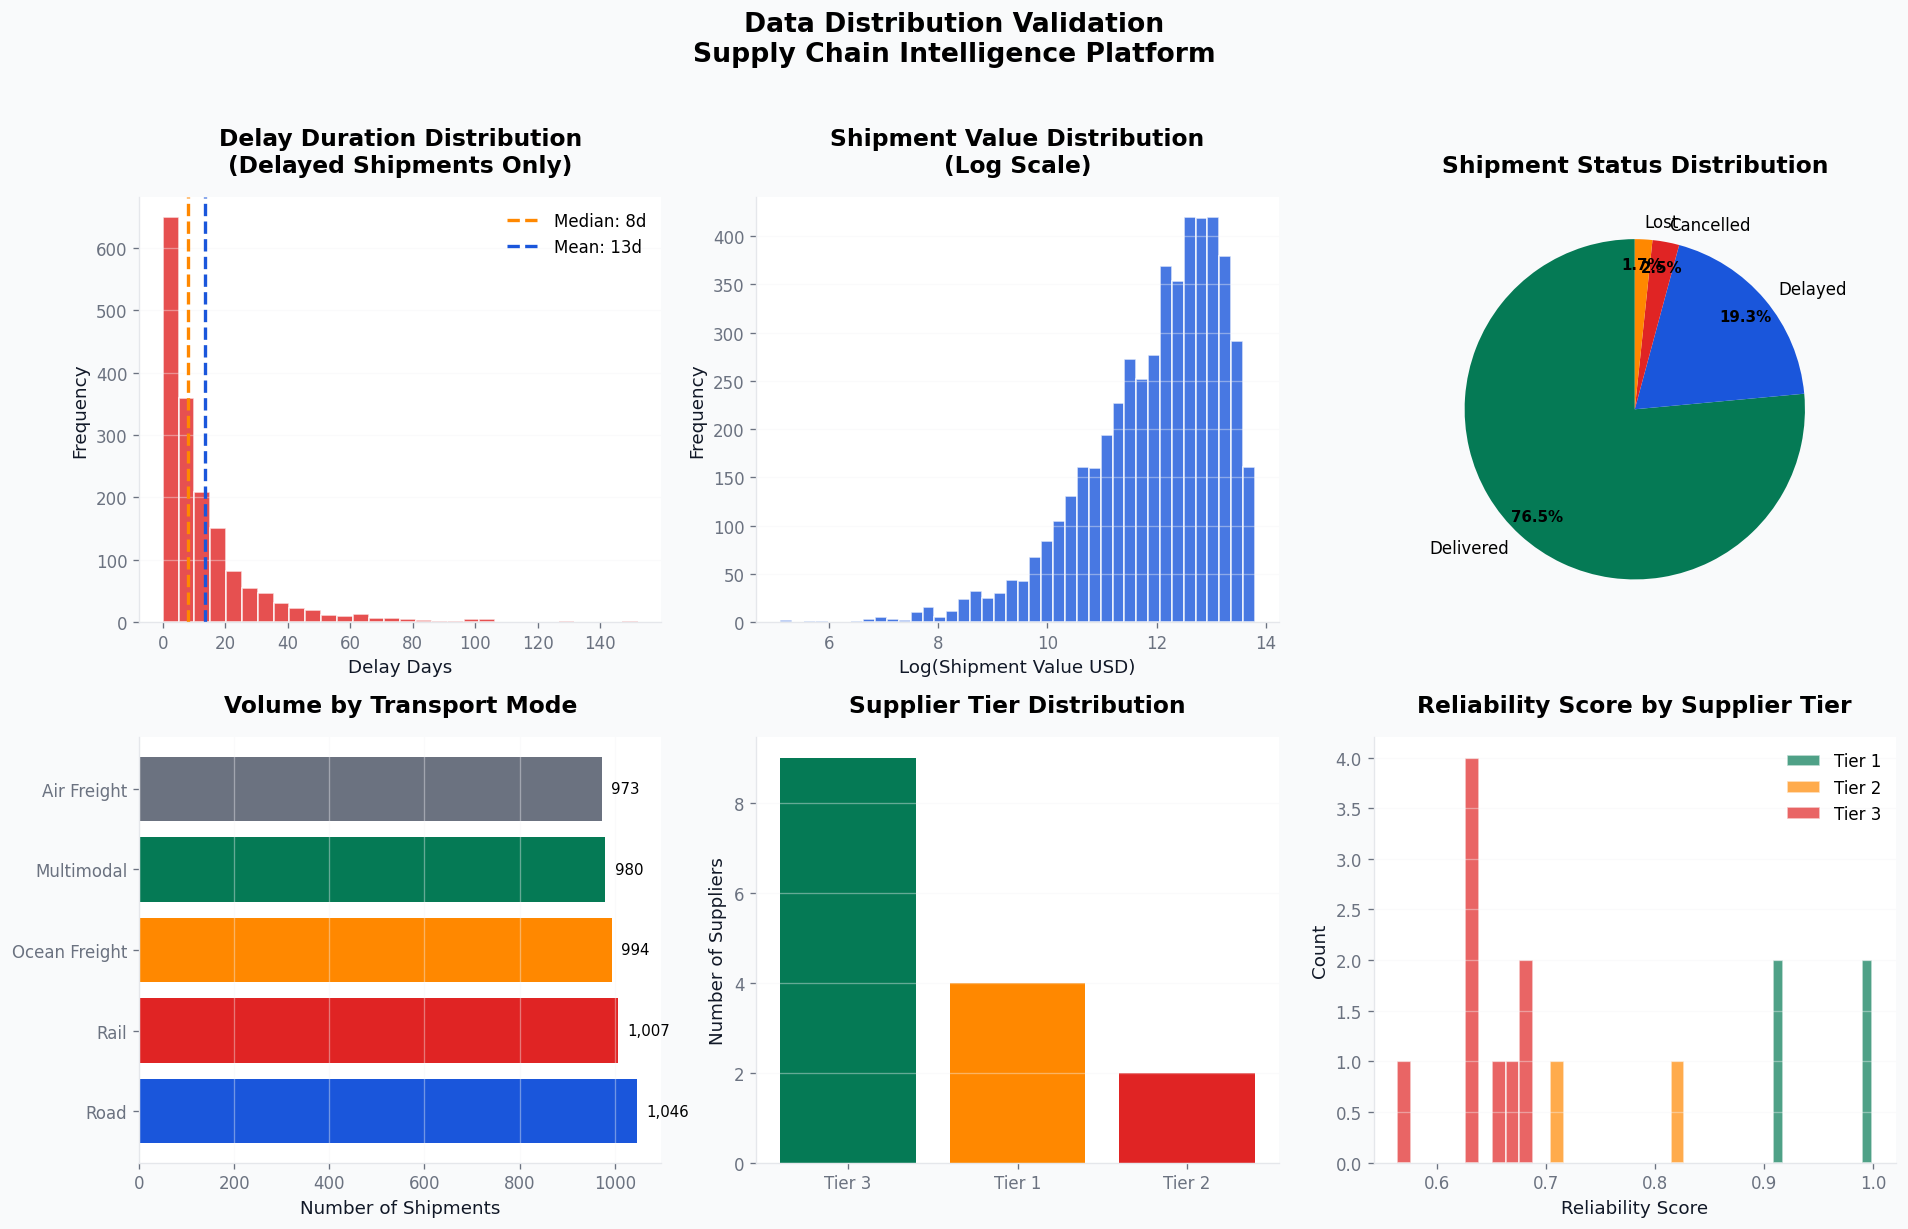


DISTRIBUTION INSIGHT
─────────────────────
Mean delay:   13.4 days
Median delay: 8.0 days
Max delay:    152 days

Mean > Median signals RIGHT SKEW
→ A few extreme delays pull the
  average up significantly.
→ Recommend using MEDIAN as
  primary metric, not mean.



In [5]:
# ── CELL 4: Distribution Analysis ────────────────────────────────
# Business: Validates that our synthetic data looks realistic

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Data Distribution Validation\nSupply Chain Intelligence Platform",
             fontsize=16, fontweight="bold", y=1.02)

s = dfs["shipments"]

# Plot 1: Delay Days Distribution
ax = axes[0, 0]
delayed_only = s[s["is_delayed"] == True]["delay_days"]
ax.hist(delayed_only, bins=30, color=COLORS["danger"],
        alpha=0.8, edgecolor="white")
ax.set_title("Delay Duration Distribution\n(Delayed Shipments Only)")
ax.set_xlabel("Delay Days")
ax.set_ylabel("Frequency")
ax.axvline(delayed_only.median(), color=COLORS["warning"],
           ls="--", lw=2, label=f"Median: {delayed_only.median():.0f}d")
ax.axvline(delayed_only.mean(), color=COLORS["primary"],
           ls="--", lw=2, label=f"Mean: {delayed_only.mean():.0f}d")
ax.legend()
ax.grid(axis="y", alpha=0.4)

# BUSINESS INSIGHT embedded in code
insight_1 = f"""
DISTRIBUTION INSIGHT
─────────────────────
Mean delay:   {delayed_only.mean():.1f} days
Median delay: {delayed_only.median():.1f} days
Max delay:    {delayed_only.max():.0f} days

Mean > Median signals RIGHT SKEW
→ A few extreme delays pull the
  average up significantly.
→ Recommend using MEDIAN as
  primary metric, not mean.
"""

# Plot 2: Shipment Value Distribution
ax = axes[0, 1]
ax.hist(np.log1p(s["shipment_value_usd"]), bins=40,
        color=COLORS["primary"], alpha=0.8, edgecolor="white")
ax.set_title("Shipment Value Distribution\n(Log Scale)")
ax.set_xlabel("Log(Shipment Value USD)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.4)

# Plot 3: Status Distribution (Pie)
ax = axes[0, 2]
status_counts = s["status"].value_counts()
colors_pie = [COLORS["success"], COLORS["primary"],
              COLORS["danger"], COLORS["warning"], COLORS["neutral"]]
wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie[:len(status_counts)],
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontweight("bold")
    text.set_fontsize(9)
ax.set_title("Shipment Status Distribution")

# Plot 4: Transport Mode Volume
ax = axes[1, 0]
mode_counts = s["transport_mode"].value_counts()
bars = ax.barh(mode_counts.index, mode_counts.values,
               color=PALETTE[:len(mode_counts)])
ax.set_title("Volume by Transport Mode")
ax.set_xlabel("Number of Shipments")
for bar, val in zip(bars, mode_counts.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.4)

# Plot 5: Supplier Tier Distribution
ax = axes[1, 1]
tier_counts = dfs["suppliers"]["tier"].value_counts()
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=[COLORS["success"], COLORS["warning"], COLORS["danger"]])
ax.set_title("Supplier Tier Distribution")
ax.set_ylabel("Number of Suppliers")
add_value_labels(ax, fmt="{:.0f}", color=COLORS["text"], offset=-8)
ax.grid(axis="y", alpha=0.4)

# Plot 6: Reliability Score by Tier
ax = axes[1, 2]
for tier, color in zip(["Tier 1","Tier 2","Tier 3"],
                        [COLORS["success"], COLORS["warning"], COLORS["danger"]]):
    data = dfs["suppliers"][dfs["suppliers"]["tier"] == tier]["reliability_score"]
    ax.hist(data, bins=10, alpha=0.7, label=tier, color=color, edgecolor="white")
ax.set_title("Reliability Score by Supplier Tier")
ax.set_xlabel("Reliability Score")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
save_figure(fig, "01_data_distributions")
plt.show()

print(insight_1)

In [6]:
# ── CELL 5: Data Quality Scorecard ────────────────────────────────
# Output: A single quality score — professional QA output

print("\n" + "═"*55)
print("  DATA QUALITY SCORECARD")
print("═"*55)

s = dfs["shipments"]
checks = {
    "No duplicate shipment IDs"          : s["shipment_id"].is_unique,
    "No negative delay days"             : (s["delay_days"] >= 0).all(),
    "Delivery date after ship date"      : (
        s.dropna(subset=["actual_delivery_date"])
         .apply(lambda r: r["actual_delivery_date"] >= r["ship_date"], axis=1).all()
    ),
    "Shipment value > 0"                 : (s["shipment_value_usd"] > 0).all(),
    "All supplier IDs valid"             : s["supplier_id"].isin(
        dfs["suppliers"]["supplier_id"]).all(),
    "All product IDs valid"              : s["product_id"].isin(
        dfs["products"]["product_id"]).all(),
    "Status values in allowed set"       : s["status"].isin(
        ["Delivered","In Transit","Delayed","Cancelled","Lost"]).all(),
}

passed = sum(checks.values())
total  = len(checks)

for check, result in checks.items():
    icon = "✅" if result else "❌"
    print(f"  {icon}  {check}")

print(f"\n  Quality Score: {passed}/{total} checks passed")
print(f"  Data Grade: {'A — Production Ready' if passed==total else 'B — Minor Issues'}")
print("═"*55)


═══════════════════════════════════════════════════════
  DATA QUALITY SCORECARD
═══════════════════════════════════════════════════════
  ✅  No duplicate shipment IDs
  ✅  No negative delay days
  ✅  Delivery date after ship date
  ✅  Shipment value > 0
  ✅  All supplier IDs valid
  ✅  All product IDs valid
  ✅  Status values in allowed set

  Quality Score: 7/7 checks passed
  Data Grade: A — Production Ready
═══════════════════════════════════════════════════════
